In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("telcom_data (2).xlsx")

df.head()



,Bearer Id,Start,Start ms,End,End ms,Dur. (ms),IMSI,MSISDN/Number,IMEI,Last Location Name,...,Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
0,13114483460844900352,2019-04-04 12:01:18,770.0,2019-04-25 14:35:31,662.0,1823652.0,2.082014e+14,3.366496e+10,3.552121e+13,9164566995485190,...,15854611.0,2501332.0,8198936.0,9656251.0,278082303.0,14344150.0,171744450.0,8814393.0,36749741.0,308879636.0
1,13114483482878900224,2019-04-09 13:04:04,235.0,2019-04-25 08:15:48,606.0,1365104.0,2.082019e+14,3.368185e+10,3.579401e+13,L77566A,...,20247395.0,19111729.0,18338413.0,17227132.0,608750074.0,1170709.0,526904238.0,15055145.0,53800391.0,653384965.0
2,13114483484080500736,2019-04-09 17:42:11,1.0,2019-04-25 11:58:13,652.0,1361762.0,2.082003e+14,3.376063e+10,3.528151e+13,D42335A,...,19725661.0,14699576.0,17587794.0,6163408.0,229584621.0,395630.0,410692588.0,4215763.0,27883638.0,279807335.0
3,13114483485442799616,2019-04-10 00:31:25,486.0,2019-04-25 07:36:35,171.0,1321509.0,2.082014e+14,3.375034e+10,3.535661e+13,T21824A,...,21388122.0,15146643.0,13994646.0,1097942.0,799538153.0,10849722.0,749039933.0,12797283.0,43324218.0,846028530.0
4,13114483499480700928,2019-04-12 20:10:23,565.0,2019-04-25 10:40:32,954.0,1089009.0,2.082014e+14,3.369980e+10,3.540701e+13,D88865A,...,15259380.0,18962873.0,17124581.0,415218.0,527707248.0,3529801.0,550709500.0,13910322.0,38542814.0,569138589.0


## Step 2: Load Dataset

We load the dataset using Pandas.

### Why?
- Converts Excel file into a DataFrame
- Allows us to analyze structured data

`df.head()` helps preview the dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150001 entries, 0 to 150000
Data columns (total 55 columns):
 #   Column                                    Non-Null Count   Dtype         
---  ------                                    --------------   -----         
 0   Bearer Id                                 150001 non-null  object        
 1   Start                                     150000 non-null  datetime64[ns]
 2   Start ms                                  150000 non-null  float64       
 3   End                                       150000 non-null  datetime64[ns]
 4   End ms                                    150000 non-null  float64       
 5   Dur. (ms)                                 150000 non-null  float64       
 6   IMSI                                      149431 non-null  float64       
 7   MSISDN/Number                             148935 non-null  float64       
 8   IMEI                                      149429 non-null  float64       
 9   Last Location N

In [4]:
df.describe()




,Start,Start ms,End,End ms,Dur. (ms),IMSI,MSISDN/Number,IMEI,Avg RTT DL (ms),Avg RTT UL (ms),...,Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
count,150000,150000.000000,150000,150000.000000,1.500000e+05,1.494310e+05,1.489350e+05,1.494290e+05,122172.000000,122189.000000,...,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500000e+05,1.500000e+05
mean,2019-04-26 12:36:38.953740032,499.188200,2019-04-27 17:40:08.059673344,498.800880,1.046086e+05,2.082016e+14,4.188282e+10,4.847455e+13,109.795706,17.662883,...,1.163407e+07,1.100941e+07,1.162685e+07,1.100175e+07,4.220447e+08,8.288398e+06,4.211005e+08,8.264799e+06,4.112121e+07,4.546434e+08
min,2019-04-04 12:01:18,0.000000,2019-04-24 22:59:58,0.000000,7.142000e+03,2.040471e+14,3.360100e+10,4.400152e+11,0.000000,0.000000,...,5.300000e+01,1.050000e+02,4.200000e+01,3.500000e+01,2.516000e+03,5.900000e+01,3.290000e+03,1.480000e+02,2.866892e+06,7.114041e+06
25%,2019-04-25 00:26:00.750000128,250.000000,2019-04-26 07:30:11.500000,251.000000,5.744050e+04,2.082014e+14,3.365130e+10,3.546071e+13,32.000000,2.000000,...,5.833501e+06,5.517965e+06,5.777156e+06,5.475981e+06,2.104733e+08,4.128476e+06,2.101869e+08,4.145943e+06,3.322201e+07,2.431068e+08
50%,2019-04-26 08:51:24.500000,499.000000,2019-04-27 23:02:05,500.000000,8.639900e+04,2.082015e+14,3.366371e+10,3.572201e+13,45.000000,5.000000,...,1.161602e+07,1.101345e+07,1.164222e+07,1.099638e+07,4.234081e+08,8.291208e+06,4.218030e+08,8.267071e+06,4.114331e+07,4.558411e+08
75%,2019-04-27 18:18:59.750000128,749.000000,2019-04-29 07:15:07.500000,750.000000,1.324302e+05,2.082018e+14,3.368349e+10,8.611970e+13,70.000000,15.000000,...,1.744852e+07,1.651556e+07,1.747048e+07,1.650727e+07,6.331742e+08,1.243162e+07,6.316918e+08,1.238415e+07,4.903424e+07,6.657055e+08
max,2019-04-29 07:28:43,999.000000,2019-04-30 23:59:27,999.000000,1.859336e+06,2.140743e+14,8.823971e+14,9.900120e+13,96923.000000,7120.000000,...,2.325910e+07,2.201196e+07,2.325919e+07,2.201196e+07,8.434419e+08,1.655879e+07,8.434425e+08,1.655882e+07,7.833131e+07,9.029696e+08
std,NaN,288.611834,NaN,288.097653,8.103762e+04,2.148809e+10,2.447443e+12,2.241637e+13,619.782739,84.793524,...,6.710569e+06,6.345423e+06,6.725218e+06,6.359490e+06,2.439675e+08,4.782700e+06,2.432050e+08,4.769004e+06,1.127639e+07,2.441429e+08



##  Step 3 (Continued): Statistical Summary

We generate a statistical summary of the dataset.

### What it shows:
- Mean → average value
- Min / Max → range of values
- Standard deviation → spread of data

### Why?
- Helps understand distribution of numeric data
- Identifies unusual values
- Prepares us for data cleaning

This step gives a quick overview of the dataset

CHECK MISSING VALUES

In [5]:
df.isnull().sum()


Bearer Id                                        0
Start                                            1
Start ms                                         1
End                                              1
End ms                                           1
Dur. (ms)                                        1
IMSI                                           570
MSISDN/Number                                 1066
IMEI                                           572
Last Location Name                            1153
Avg RTT DL (ms)                              27829
Avg RTT UL (ms)                              27812
Avg Bearer TP DL (kbps)                          1
Avg Bearer TP UL (kbps)                          1
TCP DL Retrans. Vol (Bytes)                  88146
TCP UL Retrans. Vol (Bytes)                  96649
DL TP < 50 Kbps (%)                            754
50 Kbps < DL TP < 250 Kbps (%)                 754
250 Kbps < DL TP < 1 Mbps (%)                  754
DL TP > 1 Mbps (%)             

##  Step 4: Check Missing Values

We check how many missing values exist in each column.

### Why?
- Missing data can affect analysis
- Must be handled before modeling

 Helps identify which columns need cleaning
 

HANDLE MISSING VALUES


In [6]:
df = df.fillna(df.mean(numeric_only=True))
df


,Bearer Id,Start,Start ms,End,End ms,Dur. (ms),IMSI,MSISDN/Number,IMEI,Last Location Name,...,Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
0,13114483460844900352,2019-04-04 12:01:18,770.0000,2019-04-25 14:35:31,662.00000,1.823652e+06,2.082014e+14,3.366496e+10,3.552121e+13,9164566995485190,...,1.585461e+07,2.501332e+06,8.198936e+06,9.656251e+06,2.780823e+08,1.434415e+07,1.717444e+08,8.814393e+06,3.674974e+07,3.088796e+08
1,13114483482878900224,2019-04-09 13:04:04,235.0000,2019-04-25 08:15:48,606.00000,1.365104e+06,2.082019e+14,3.368185e+10,3.579401e+13,L77566A,...,2.024740e+07,1.911173e+07,1.833841e+07,1.722713e+07,6.087501e+08,1.170709e+06,5.269042e+08,1.505514e+07,5.380039e+07,6.533850e+08
2,13114483484080500736,2019-04-09 17:42:11,1.0000,2019-04-25 11:58:13,652.00000,1.361762e+06,2.082003e+14,3.376063e+10,3.528151e+13,D42335A,...,1.972566e+07,1.469958e+07,1.758779e+07,6.163408e+06,2.295846e+08,3.956300e+05,4.106926e+08,4.215763e+06,2.788364e+07,2.798073e+08
3,13114483485442799616,2019-04-10 00:31:25,486.0000,2019-04-25 07:36:35,171.00000,1.321509e+06,2.082014e+14,3.375034e+10,3.535661e+13,T21824A,...,2.138812e+07,1.514664e+07,1.399465e+07,1.097942e+06,7.995382e+08,1.084972e+07,7.490399e+08,1.279728e+07,4.332422e+07,8.460285e+08
4,13114483499480700928,2019-04-12 20:10:23,565.0000,2019-04-25 10:40:32,954.00000,1.089009e+06,2.082014e+14,3.369980e+10,3.540701e+13,D88865A,...,1.525938e+07,1.896287e+07,1.712458e+07,4.152180e+05,5.277072e+08,3.529801e+06,5.507095e+08,1.391032e+07,3.854281e+07,5.691386e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149996,7277825670196679680,2019-04-29 07:28:42,451.0000,2019-04-30 06:02:33,214.00000,8.123000e+04,2.082022e+14,3.365069e+10,3.548311e+13,D20434A,...,1.619167e+07,1.176343e+07,1.788370e+07,1.967816e+07,5.266097e+08,9.197207e+06,3.264510e+06,1.348742e+07,5.762885e+07,5.741753e+08
149997,7349883264234609664,2019-04-29 07:28:42,483.0000,2019-04-30 10:41:33,187.00000,9.797000e+04,2.082019e+14,3.366345e+10,3.566051e+13,D10223C,...,1.387723e+07,8.288284e+06,1.935015e+07,2.129315e+07,6.268931e+08,4.735033e+06,7.121804e+08,2.457758e+06,3.913508e+07,6.666488e+08
149998,13114483573367300096,2019-04-29 07:28:43,283.0000,2019-04-30 10:46:12,810.00000,9.824900e+04,2.082017e+14,3.362189e+10,3.572121e+13,T51102A,...,2.266051e+07,1.855903e+06,9.963942e+06,5.065760e+06,5.535395e+08,1.339432e+07,1.211009e+08,1.131473e+07,3.491222e+07,5.927864e+08
149999,13114483573367300096,2019-04-29 07:28:43,696.0000,2019-04-30 10:40:34,327.00000,9.791000e+04,2.082021e+14,3.361962e+10,8.618620e+13,L88342B,...,8.817106e+06,8.305402e+06,3.322253e+06,1.317259e+07,3.525370e+08,2.529475e+06,8.147131e+08,1.406930e+06,2.962610e+07,3.718959e+08


##  Step 5: Handle Missing Values

We replace missing values with the mean.

### Why?
- Simple and effective method
- Maintains data distribution

 Now dataset is cleaner and ready for analysis

CHECK DUPLICATES


In [7]:
df.duplicated().sum()


np.int64(0)

##  Step 6: Check Duplicate Values

We check for duplicate rows.

### Why?
- Duplicate rows can bias analysis
- Must be removed for accurate results
- 


REMOVE DUPLICATES


In [11]:
df = df.drop_duplicates()


##  Step 7: Remove Duplicate Values

We remove duplicate rows.

### Why?
- Ensures each record is unique
- Improves data quality


VERIFY CLEANING


In [12]:
print(df.shape)
df.duplicated().sum()


(150001, 55)


np.int64(0)

In [ ]:
##  Step 8: Verify Cleaning

We verify that:
- Duplicate rows are removed
- Dataset shape is correct

 Confirms data is clean and ready
    

OUTLIER DETECTION


In [13]:
import numpy as np

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    
    print(col, ":", outliers)
    

Start ms : 0
End ms : 0
Dur. (ms) : 7184
IMSI : 13250
MSISDN/Number : 24742
IMEI : 0
Avg RTT DL (ms) : 7718
Avg RTT UL (ms) : 8975
Avg Bearer TP DL (kbps) : 13235
Avg Bearer TP UL (kbps) : 21531
TCP DL Retrans. Vol (Bytes) : 2525
TCP UL Retrans. Vol (Bytes) : 1320
DL TP < 50 Kbps (%) : 18352
50 Kbps < DL TP < 250 Kbps (%) : 15220
250 Kbps < DL TP < 1 Mbps (%) : 29751
DL TP > 1 Mbps (%) : 22846
UL TP < 10 Kbps (%) : 22123
10 Kbps < UL TP < 50 Kbps (%) : 32791
50 Kbps < UL TP < 300 Kbps (%) : 5335
UL TP > 300 Kbps (%) : 3249
HTTP DL (Bytes) : 5415
HTTP UL (Bytes) : 6238
Activity Duration DL (ms) : 26660
Activity Duration UL (ms) : 26022
Dur. (ms).1 : 7184
Nb of sec with 125000B < Vol DL : 7760
Nb of sec with 1250B < Vol UL < 6250B : 5770
Nb of sec with 31250B < Vol DL < 125000B : 9173
Nb of sec with 37500B < Vol UL : 19747
Nb of sec with 6250B < Vol DL < 31250B : 10799
Nb of sec with 6250B < Vol UL < 37500B : 38158
Nb of sec with Vol DL < 6250B : 23854
Nb of sec with Vol UL < 1250B : 245

##  Step 9: Outlier Detection

We detect outliers using the IQR (Interquartile Range) method.

### What is an outlier?
- A value that is extremely high or low compared to others

### How it works:
- Q1 = 25th percentile  
- Q3 = 75th percentile  
- IQR = Q3 - Q1  

Outliers are:
- Below → Q1 - 1.5 × IQR  
- Above → Q3 + 1.5 × IQR  

### Why?
- Outliers can distort analysis
- They affect clustering and statistical results

 This step helps identify extreme values in the dataset

HANDLE OUTLIERS


In [15]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = np.where(df[col] > upper, upper, df[col])
    df[col] = np.where(df[col] < lower, lower, df[col])
    
    

##  Step 10: Handle Outliers

We handle outliers using the capping method (Winsorization).

### What we did:
- Values above upper limit → replaced with upper limit
- Values below lower limit → replaced with lower limit

### Why?
- Keeps dataset size unchanged
- Prevents extreme values from affecting results

 This ensures stable and reliable analysis


VERIFY OUTLIERS


In [16]:
df.describe()


,Start,Start ms,End,End ms,Dur. (ms),IMSI,MSISDN/Number,IMEI,Avg RTT DL (ms),Avg RTT UL (ms),...,Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
count,150000,150001.000000,150000,150001.000000,150001.000000,1.500010e+05,1.500010e+05,1.500010e+05,150001.000000,150001.000000,...,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05
mean,2019-04-26 12:36:38.953740032,499.188200,2019-04-27 17:40:08.059673344,498.800880,99572.128983,2.082015e+14,3.366999e+10,4.847455e+13,72.862020,12.037797,...,1.163407e+07,1.100941e+07,1.162685e+07,1.100175e+07,4.220447e+08,8.288398e+06,4.211005e+08,8.264799e+06,4.112120e+07,4.546434e+08
min,2019-04-04 12:01:18,0.000000,2019-04-24 22:59:58,0.000000,7142.000000,2.082008e+14,3.360168e+10,4.400152e+11,0.000000,0.000000,...,5.300000e+01,1.050000e+02,4.200000e+01,3.500000e+01,2.516000e+03,5.900000e+01,3.290000e+03,1.480000e+02,9.503716e+06,7.114041e+06
25%,2019-04-25 00:26:00.750000128,250.000000,2019-04-26 07:30:11.500000,251.000000,57442.000000,2.082014e+14,3.365151e+10,3.546261e+13,35.000000,3.000000,...,5.833501e+06,5.517965e+06,5.777156e+06,5.475981e+06,2.104733e+08,4.128476e+06,2.101869e+08,4.145943e+06,3.322203e+07,2.431072e+08
50%,2019-04-26 08:51:24.500000,499.000000,2019-04-27 23:02:05,500.000000,86399.000000,2.082015e+14,3.366380e+10,3.572241e+13,54.000000,7.000000,...,1.161602e+07,1.101345e+07,1.164222e+07,1.099638e+07,4.234081e+08,8.291208e+06,4.218030e+08,8.267071e+06,4.114324e+07,4.558409e+08
75%,2019-04-27 18:18:59.750000128,749.000000,2019-04-29 07:15:07.500000,750.000000,132430.000000,2.082018e+14,3.368473e+10,8.611970e+13,109.795706,17.662883,...,1.744852e+07,1.651556e+07,1.747048e+07,1.650727e+07,6.331742e+08,1.243162e+07,6.316918e+08,1.238415e+07,4.903424e+07,6.657051e+08
max,2019-04-29 07:28:43,999.000000,2019-04-30 23:59:27,999.000000,244912.000000,2.082023e+14,3.373456e+10,9.900120e+13,221.989265,39.657207,...,2.325910e+07,2.201196e+07,2.325919e+07,2.201196e+07,8.434419e+08,1.655879e+07,8.434425e+08,1.655882e+07,7.275255e+07,9.029696e+08
std,NaN,288.610872,NaN,288.096693,59084.184127,3.925668e+08,3.532589e+07,2.237359e+13,51.361714,11.040917,...,6.710569e+06,6.345423e+06,6.725218e+06,6.359490e+06,2.439675e+08,4.782700e+06,2.432050e+08,4.769004e+06,1.126923e+07,2.441421e+08


##  Step 11: Verify Outlier Handling

We verify that extreme values are controlled.

### Why?
- Ensures preprocessing worked correctly
- Confirms data is ready for analysis

 Dataset is now clean and reliable

     

TOP 10 HANDSETS


In [17]:
df['Handset Type'].value_counts().head(10)


Handset Type
Huawei B528S-23A                19752
Apple iPhone 6S (A1688)          9419
Apple iPhone 6 (A1586)           9023
undefined                        8987
Apple iPhone 7 (A1778)           6326
Apple iPhone Se (A1723)          5187
Apple iPhone 8 (A1905)           4993
Apple iPhone Xr (A2105)          4568
Samsung Galaxy S8 (Sm-G950F)     4520
Apple iPhone X (A1901)           3813
Name: count, dtype: int64

##  Step 12: Top 10 Handsets

We identify the top 10 most used handset types.

### Why?
- Helps understand customer device preferences
- Useful for marketing and service optimization

 This helps us understand:
- Which devices are most popular
- Market trends in handset usage
  

TOP 3 MANUFACTURERS


In [18]:
df['Handset Manufacturer'].value_counts().head(3)


Handset Manufacturer
Apple      59565
Samsung    40839
Huawei     34423
Name: count, dtype: int64

##  Step 13: Top 3 Handset Manufacturers

We identify the top 3 handset manufacturers.

### Why?
- Shows which brands dominate the market
- Helps in strategic decision making

 This helps us understand:
- Market share of different brands
- Where to focus business efforts

TOP 5 HANDSETS PER MANUFACTURER


In [19]:
top3 = df['Handset Manufacturer'].value_counts().head(3).index

for brand in top3:
    print(f"\nTop devices for {brand}:")
    print(df[df['Handset Manufacturer'] == brand]['Handset Type'].value_counts().head(5))
    


Top devices for Apple:
Handset Type
Apple iPhone 6S (A1688)    9419
Apple iPhone 6 (A1586)     9023
Apple iPhone 7 (A1778)     6326
Apple iPhone Se (A1723)    5187
Apple iPhone 8 (A1905)     4993
Name: count, dtype: int64

Top devices for Samsung:
Handset Type
Samsung Galaxy S8 (Sm-G950F)    4520
Samsung Galaxy A5 Sm-A520F      3724
Samsung Galaxy J5 (Sm-J530)     3696
Samsung Galaxy J3 (Sm-J330)     3484
Samsung Galaxy S7 (Sm-G930X)    3199
Name: count, dtype: int64

Top devices for Huawei:
Handset Type
Huawei B528S-23A                  19752
Huawei E5180                       2079
Huawei P20 Lite Huawei Nova 3E     2021
Huawei P20                         1480
Huawei Y6 2018                      997
Name: count, dtype: int64


##  Step 14: Top 5 Handsets per Manufacturer

We identify the top 5 handset models for each of the top 3 manufacturers.

### Why?
- Helps understand popular models within each brand
- Useful for targeted marketing

 This helps us:
- Identify best-selling models
- Understand user preferences at model level
 

VISUALIZATION

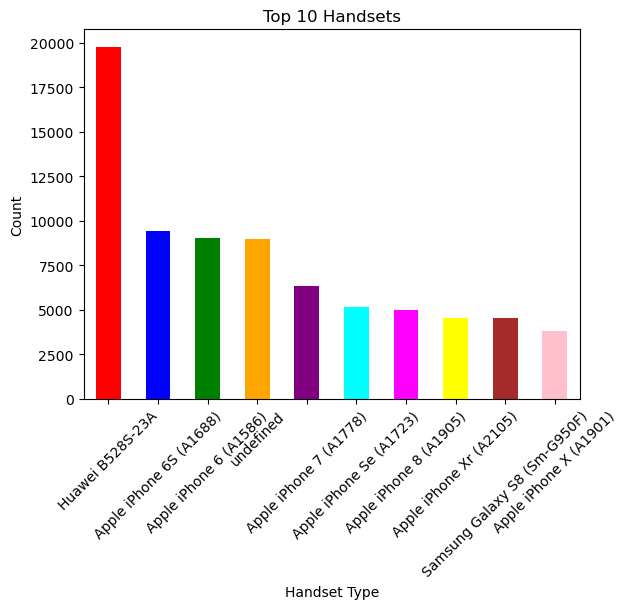

In [20]:
import matplotlib.pyplot as plt

colors = ['red', 'blue', 'green', 'orange', 'purple',
          'cyan', 'magenta', 'yellow', 'brown', 'pink']

df['Handset Type'].value_counts().head(10).plot(
    kind='bar',
    color=colors
)

plt.title("Top 10 Handsets")
plt.xlabel("Handset Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


##  Step 15: Visualization of Top Handsets

We visualize the top 10 handsets using a bar chart.

### Why?
- Makes patterns easier to understand
- Useful for presentations and dashboards

 This helps us:
- Quickly identify most popular devices
- Communicate insights effectively
- 

USER-LEVEL AGGREGATION


In [21]:
user_df = df.groupby('MSISDN/Number').agg({
    'Dur. (ms)': 'sum',
    'Total DL (Bytes)': 'sum',
    'Total UL (Bytes)': 'sum'
}).reset_index()

user_df['Total Data'] = user_df['Total DL (Bytes)'] + user_df['Total UL (Bytes)']

user_df.head()


,MSISDN/Number,Dur. (ms),Total DL (Bytes),Total UL (Bytes),Total Data
0,3.360168e+10,34112179.0,1.682756e+11,1.467565e+10,1.829512e+11
1,3.360171e+10,38503.0,2.934050e+08,4.621197e+07,3.396170e+08
2,3.360171e+10,52478.0,8.621012e+08,3.850972e+07,9.006109e+08
3,3.360171e+10,120298.0,1.498037e+09,8.929984e+07,1.587337e+09
4,3.360171e+10,176022.0,1.333844e+08,4.494626e+07,1.783307e+08


##  Step 16: User Behavior Aggregation

We aggregate the dataset at the user level.

### What we calculated:
- Total session duration per user
- Total download data
- Total upload data
- Total data usage

### Why?
- Original dataset is session-level (multiple rows per user)
- We convert it into user-level data

 This helps us:
- Understand user behavior
- Prepare data for clustering
 

BASIC STATISTICS


In [22]:
user_df.describe()


,MSISDN/Number,Dur. (ms),Total DL (Bytes),Total UL (Bytes),Total Data
count,9.003800e+04,9.003800e+04,9.003800e+04,9.003800e+04,9.003800e+04
mean,3.365731e+10,1.658846e+05,7.574243e+08,6.850687e+07,8.259312e+08
std,2.306721e+07,8.112136e+06,3.673617e+10,3.343148e+09,4.007920e+10
min,3.360168e+10,7.146000e+03,9.046209e+06,9.503716e+06,3.324901e+07
25%,3.364977e+10,7.007000e+04,3.148955e+08,3.641345e+07,3.585559e+08
50%,3.366171e+10,1.020740e+05,5.709107e+08,4.680074e+07,6.183490e+08
75%,3.366802e+10,1.727990e+05,8.069726e+08,6.558001e+07,8.569936e+08
max,3.373456e+10,2.433741e+09,1.102166e+13,1.003051e+12,1.202471e+13


##  Step 17: Basic Statistics

We compute summary statistics for user data.

### What it shows:
- Mean → average usage
- Min / Max → range of values
- Standard deviation → variability

### Why?
- Helps identify heavy users vs low users
- Provides overall understanding of data distribution

 This gives a quick overview of user activity
 

HISTOGRAM


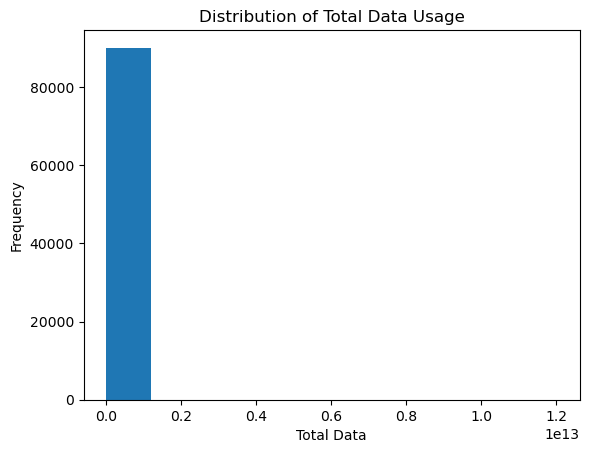

In [23]:
import matplotlib.pyplot as plt

plt.hist(user_df['Total Data'])
plt.title("Distribution of Total Data Usage")
plt.xlabel("Total Data")
plt.ylabel("Frequency")
plt.show()


##  Step 18: Data Distribution

We visualize how total data usage is distributed.

### Why?
- Helps identify:
  - Heavy users
  - Low users
  - Skewness

 Insight:
- Few users consume very high data
- Most users consume moderate or low data
 

SCATTER PLOT


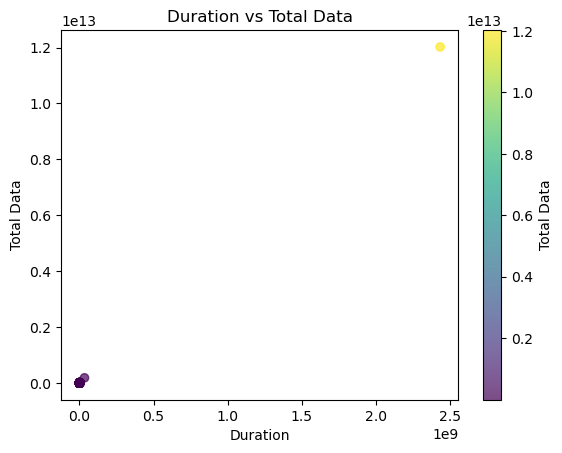

In [24]:
import matplotlib.pyplot as plt

plt.scatter(
    user_df['Dur. (ms)'],
    user_df['Total Data'],
    c=user_df['Total Data'],   # color based on values
    cmap='viridis',            # color palette
    alpha=0.7
)

plt.colorbar(label='Total Data')  # shows color scale
plt.xlabel("Duration")
plt.ylabel("Total Data")
plt.title("Duration vs Total Data")
plt.show()


##  Step 19: Bivariate Analysis

We analyze the relationship between:
- Session duration
- Total data usage

### Why?
- Helps understand user behavior patterns
- Identifies relationships between variables

 Insight:
- Users with longer sessions often use more data
- But some users behave differently
 

CORRELATION ANALYSIS


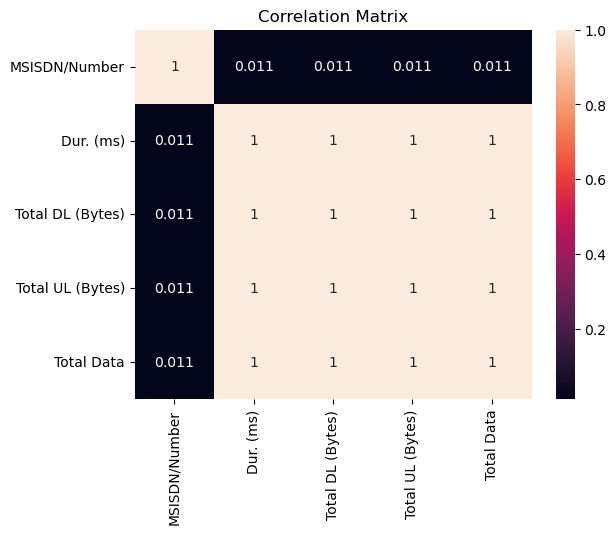

In [25]:

corr = user_df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()


##  Step 20: Correlation Analysis

We analyze relationships between variables.

### What it shows:
- Strength of relationship between features

### Why?
- Helps identify important variables
- Helps understand dependencies

 Insight:
- Strong correlation between duration and data usage indicates user behavior patterns
 

DATA SCALING


In [27]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(
    user_df[['Dur. (ms)', 'Total Data']]
)



##  Step 21: Data Scaling

We normalize the data using Min-Max Scaling.

### Why?
- K-Means uses distance to form clusters
- Features like "Total Data" have very large values
- Without scaling, large values dominate smaller ones

 Scaling ensures:
- Fair comparison between features
- Better clustering performance
- 

ELBOW METHOD


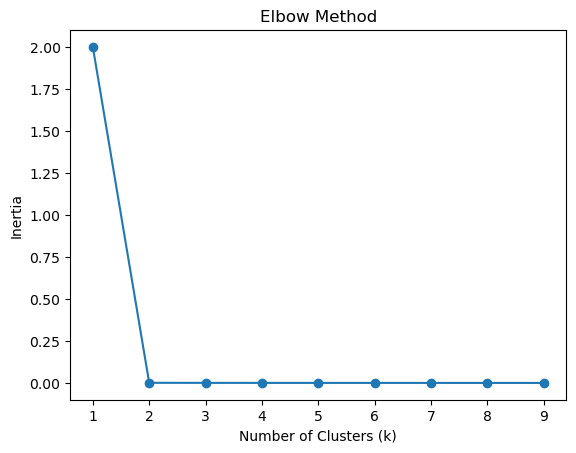

In [28]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(scaled_data)
    inertia.append(km.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


##  Step 22: Elbow Method

We use the Elbow Method to find the optimal number of clusters.

### What is Inertia?
- Measures how tightly data points are grouped within clusters

### Why?
- Helps choose the best value of K
- Avoids too many or too few clusters

 Insight:
- The "bend" in the graph indicates optimal number of clusters


APPLY K-MEANS


In [29]:
kmeans = KMeans(n_clusters=3, random_state=42)

user_df['Cluster'] = kmeans.fit_predict(scaled_data)

user_df.head()


,MSISDN/Number,Dur. (ms),Total DL (Bytes),Total UL (Bytes),Total Data,Cluster
0,3.360168e+10,34112179.0,1.682756e+11,1.467565e+10,1.829512e+11,2
1,3.360171e+10,38503.0,2.934050e+08,4.621197e+07,3.396170e+08,0
2,3.360171e+10,52478.0,8.621012e+08,3.850972e+07,9.006109e+08,0
3,3.360171e+10,120298.0,1.498037e+09,8.929984e+07,1.587337e+09,0
4,3.360171e+10,176022.0,1.333844e+08,4.494626e+07,1.783307e+08,0


##  Step 23: K-Means Clustering

We apply K-Means clustering with K = 3.

### Why?
- Project requirement specifies 3 clusters
- Helps group users based on behavior

👉 Clusters represent:
- Cluster 0 → Low usage users
- Cluster 1 → Medium usage users
- Cluster 2 → High usage users
 

VISUALIZE CLUSTERS


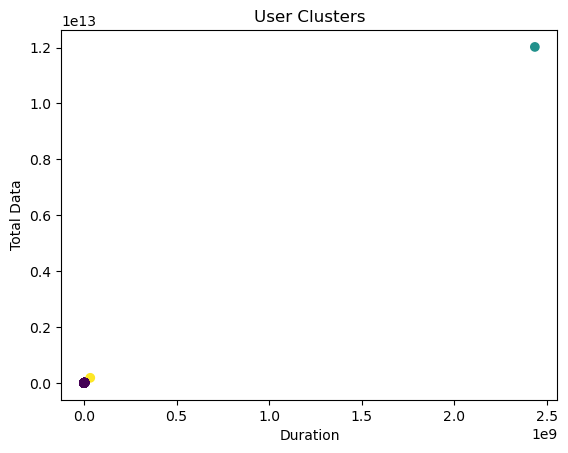

In [30]:
plt.scatter(user_df['Dur. (ms)'], user_df['Total Data'], c=user_df['Cluster'])
plt.xlabel("Duration")
plt.ylabel("Total Data")
plt.title("User Clusters")
plt.show()


##  Step 24: Cluster Visualization

We visualize user clusters using a scatter plot.

### Why?
- Helps understand grouping visually
- Makes patterns easier to interpret

 Insight:
- Different clusters represent different user behaviors
 

CLUSTER ANALYSIS


In [31]:
user_df.groupby('Cluster').mean()


,MSISDN/Number,Dur. (ms),Total DL (Bytes),Total UL (Bytes),Total Data
Cluster,,,,,
0,3.365731e+10,1.384787e+05,6.331582e+08,5.720484e+07,6.903631e+08
1,3.373456e+10,2.433741e+09,1.102166e+13,1.003051e+12,1.202471e+13
2,3.360168e+10,3.411218e+07,1.682756e+11,1.467565e+10,1.829512e+11


##  Step 25: Cluster Analysis

We analyze each cluster using average values.

### Why?
- Helps understand characteristics of each group
- Allows us to label clusters meaningfully

 Example:
- High data + high duration → Heavy users
- Low data + low duration → Light users
  

In [32]:
user_df.sort_values(by='Total Data', ascending=False).head(10)

,MSISDN/Number,Dur. (ms),Total DL (Bytes),Total UL (Bytes),Total Data,Cluster
90037,3.373456e+10,2.433741e+09,1.102166e+13,1.003051e+12,1.202471e+13,1
0,3.360168e+10,3.411218e+07,1.682756e+11,1.467565e+10,1.829512e+11,2
6173,3.361489e+10,3.897579e+06,8.156743e+09,6.894830e+08,8.846226e+09,0
12916,3.362578e+10,4.135260e+06,7.770043e+09,7.295774e+08,8.499621e+09,0
13262,3.362632e+10,4.004601e+06,7.301517e+09,6.696507e+08,7.971167e+09,0
76099,3.367588e+10,3.330261e+06,7.309542e+09,5.815688e+08,7.891111e+09,0
36788,3.365973e+10,3.490608e+06,7.081602e+09,6.242603e+08,7.705863e+09,0
62764,3.366646e+10,2.595320e+06,6.903440e+09,4.050610e+08,7.308501e+09,0
56977,3.366471e+10,2.602195e+06,6.400774e+09,4.715731e+08,6.872347e+09,0
86191,3.369879e+10,2.637433e+06,6.010556e+09,5.303431e+08,6.540899e+09,0


## Step 26: Top 10 Users by Data Usage

We identify the top 10 users based on total data consumption.

### Why?
- These users contribute the most to network usage
- They are high-value customers for the business

 Insight:
- Heavy data users are important for revenue generation
- They may need better service quality and premium plans

TOP USERS BY SESSION DURATION

In [33]:
user_df.sort_values(by='Dur. (ms)', ascending=False).head(10)

,MSISDN/Number,Dur. (ms),Total DL (Bytes),Total UL (Bytes),Total Data,Cluster
90037,3.373456e+10,2.433741e+09,1.102166e+13,1.003051e+12,1.202471e+13,1
0,3.360168e+10,3.411218e+07,1.682756e+11,1.467565e+10,1.829512e+11,2
12916,3.362578e+10,4.135260e+06,7.770043e+09,7.295774e+08,8.499621e+09,0
13262,3.362632e+10,4.004601e+06,7.301517e+09,6.696507e+08,7.971167e+09,0
6173,3.361489e+10,3.897579e+06,8.156743e+09,6.894830e+08,8.846226e+09,0
36788,3.365973e+10,3.490608e+06,7.081602e+09,6.242603e+08,7.705863e+09,0
76099,3.367588e+10,3.330261e+06,7.309542e+09,5.815688e+08,7.891111e+09,0
64854,3.366716e+10,3.111859e+06,5.052068e+09,5.663264e+08,5.618394e+09,0
402,3.360313e+10,2.853379e+06,4.540607e+09,4.355876e+08,4.976195e+09,0
13730,3.362708e+10,2.780470e+06,5.309479e+09,4.452519e+08,5.754731e+09,0


## Step 27: Top Users by Session Duration

We identify users with the longest session durations.

### Why?
- Indicates how engaged users are over time
- Shows active users on the network

 Insight:
- High duration users are highly engaged
- They may not always be high data users

CLUSTER-WISE ENGAGEMENT

In [35]:
user_df.groupby('Cluster')[['Dur. (ms)', 'Total Data']].mean()

,Dur. (ms),Total Data
Cluster,,
0,1.384787e+05,6.903631e+08
1,2.433741e+09,1.202471e+13
2,3.411218e+07,1.829512e+11


## Step 28: Cluster-wise Engagement Analysis

We analyze engagement metrics for each cluster.

### Why?
- Helps understand behavior of each user group
- Differentiates low, medium, and high usage users

 Insight:
- One cluster will represent heavy users
- One cluster will represent low engagement users

MOST ENGAGED USERS (APPLICATION LEVEL)

In [38]:
# Step 29: Calculate Total Application Data

df['Total_App_Data'] = (
    df['Social Media DL (Bytes)'] + df['Social Media UL (Bytes)'] +
    df['Google DL (Bytes)'] + df['Google UL (Bytes)'] +
    df['Email DL (Bytes)'] + df['Email UL (Bytes)'] +
    df['Youtube DL (Bytes)'] + df['Youtube UL (Bytes)'] +
    df['Netflix DL (Bytes)'] + df['Netflix UL (Bytes)'] +
    df['Gaming DL (Bytes)'] + df['Gaming UL (Bytes)'] +
    df['Other DL (Bytes)'] + df['Other UL (Bytes)']
)

# Aggregate per user and get top 10 users
top_users_app = df.groupby('MSISDN/Number')['Total_App_Data'] \
                 .sum() \
                 .sort_values(ascending=False) \
                 .head(10)

top_users_app

MSISDN/Number
3.373456e+10    2.232717e+13
3.360168e+10    3.389084e+11
3.361489e+10    1.634152e+10
3.362632e+10    1.599664e+10
3.362578e+10    1.470127e+10
3.367588e+10    1.455618e+10
3.365973e+10    1.388841e+10
3.366646e+10    1.157071e+10
3.365836e+10    1.135818e+10
3.360313e+10    1.119890e+10
Name: Total_App_Data, dtype: float64

## Step 29: Application Usage Analysis

We calculate total application data usage per user.

### Applications included:
- Social Media
- Google
- Email
- Youtube
- Netflix
- Gaming
- Other

### What we did:
- Combined download (DL) and upload (UL) data for all applications
- Aggregated total application usage per user
- Identified top 10 users based on usage

### Why?
- Helps understand how users consume data across applications
- Identifies highly engaged users
- Useful for targeted marketing and network optimization
 Insight:
- Users with highest application usage are key customers
- These users contribute significantly to network traffic

USER EXPERIENCE AGGREGATION

In [39]:

exp_df = df.groupby('MSISDN/Number').agg({
    'TCP DL Retrans. Vol (Bytes)': 'mean',
    'Avg RTT DL (ms)': 'mean',
    'Avg Bearer TP DL (kbps)': 'mean',
    'Handset Type': 'first'
}).reset_index()

exp_df.head()

,MSISDN/Number,TCP DL Retrans. Vol (Bytes),Avg RTT DL (ms),Avg Bearer TP DL (kbps),Handset Type
0,3.360168e+10,1.525910e+07,66.991436,9263.906685,Samsung Galaxy A5 Sm-A520F
1,3.360171e+10,2.080991e+07,110.000000,23.000000,Apple iPhone Se (A1723)
2,3.360171e+10,5.751940e+05,145.000000,7677.000000,Apple iPhone 6 (A1586)
3,3.360171e+10,1.798137e+07,104.397853,24626.750000,Samsung Galaxy S8 Plus (Sm-G955F)
4,3.360171e+10,2.080991e+07,29.000000,63.000000,Apple iPhone 7 Plus (A1784)


## Step 30: User Experience Aggregation

We aggregate network performance metrics per user.

### Metrics used:
- TCP retransmission → network reliability
- RTT (Round Trip Time) → network delay
- Throughput → internet speed
- Handset Type → user device

### Why?
- Helps evaluate user experience on the network
- Identifies performance issues

 This step helps understand how good or bad the network is for users

TOP / WORST NETWORK VALUES

In [40]:
exp_df.sort_values(by='Avg RTT DL (ms)', ascending=False).head(10)

,MSISDN/Number,TCP DL Retrans. Vol (Bytes),Avg RTT DL (ms),Avg Bearer TP DL (kbps),Handset Type
63097,3.366658e+10,4.106050e+05,221.989265,9150.0,Samsung Galaxy A5 Sm-A520F
67316,3.366795e+10,2.710703e+06,221.989265,5730.0,Samsung Galaxy Note 2
44977,3.366170e+10,1.884800e+04,221.989265,1024.0,Apple iPhone 8 (A1905)
67369,3.366797e+10,2.665161e+07,221.989265,49210.5,Samsung Galaxy S7 (Sm-G930X)
67363,3.366797e+10,1.610121e+07,221.989265,2278.0,Apple iPhone X (A1901)
16055,3.363140e+10,3.224759e+06,221.989265,44173.0,Samsung Galaxy A5 Sm-A520F
16064,3.363142e+10,2.080991e+07,221.989265,53.0,undefined
67346,3.366796e+10,1.042064e+07,221.989265,13507.0,Samsung Galaxy A6 Sm-A600Fn Ds
44982,3.366170e+10,2.981740e+05,221.989265,9130.0,Samsung Galaxy A5 Sm-A520F
16072,3.363143e+10,8.610580e+05,221.989265,1218.0,Huawei P8 Lite


In [41]:
exp_df.sort_values(by='Avg Bearer TP DL (kbps)', ascending=False).head(10)

,MSISDN/Number,TCP DL Retrans. Vol (Bytes),Avg RTT DL (ms),Avg Bearer TP DL (kbps),Handset Type
58859,3.366521e+10,7.896760e+05,50.000000,49210.5,Huawei B528S-23A
23240,3.365014e+10,1.745112e+07,107.000000,49210.5,Huawei B528S-23A
52524,3.366348e+10,1.773500e+07,96.666667,49210.5,Huawei B528S-23A
77282,3.367824e+10,2.600070e+05,85.000000,49210.5,Huawei Lld-Al00
37461,3.365989e+10,1.344052e+07,91.000000,49210.5,Huawei B528S-23A
37460,3.365989e+10,8.597779e+06,40.000000,49210.5,Huawei B528S-23A
63747,3.366679e+10,1.597004e+07,66.333333,49210.5,Huawei B528S-23A
23227,3.365013e+10,5.002539e+07,60.000000,49210.5,Huawei B528S-23A
77307,3.367829e+10,4.658740e+05,56.000000,49210.5,Samsung Galaxy A6 Sm-A600Fn Ds
63739,3.366679e+10,1.081400e+04,38.000000,49210.5,Apple iPhone 7 (A1778)


## Step 31: Network Performance Analysis

We analyze extreme values of network metrics.

### What we check:
- High RTT → poor network (high delay)
- High Throughput → good network (high speed)

### Why?
- Helps identify best and worst user experiences
- Useful for improving network quality

 Insight:
- Users with high RTT experience delays
- Users with high throughput enjoy better performance

In [42]:

exp_df.groupby('Handset Type')['Avg Bearer TP DL (kbps)'].mean().sort_values(ascending=False).head(10)

Handset Type
New-Bund Technol. Mix 2                49210.5
Huawei P9 Plus                         49210.5
Samsung Galaxy S9+                     49210.5
Samsung Galaxy Tab S2 (Sm-T719)        49210.5
Kvd Internationa. Doogee S55 Lite      49210.5
Huawei Y9 2019                         49210.5
Asustek Asus Ze550Kl Zenfone2 Laser    49210.5
Shenzhen Leagoo. Leagoo S8             49210.5
Xiaomi Communica. Mi 6                 49210.5
Huawei Pele                            49210.5
Name: Avg Bearer TP DL (kbps), dtype: float64

## Step 32: Experience by Handset Type

We analyze how device type affects network performance.

### Why?
- Some devices perform better than others
- Helps identify device-related issues
 
 Insight:
- Certain handset types provide better performance
- Useful for device-based optimization

EXPERIENCE CLUSTERING

In [43]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

# Select features
exp_features = exp_df[['TCP DL Retrans. Vol (Bytes)', 
                       'Avg RTT DL (ms)', 
                       'Avg Bearer TP DL (kbps)']]

# Scale
scaler = MinMaxScaler()
exp_scaled = scaler.fit_transform(exp_features)

# KMeans
kmeans_exp = KMeans(n_clusters=3, random_state=42)
exp_df['Exp_Cluster'] = kmeans_exp.fit_predict(exp_scaled)

exp_df.head()

,MSISDN/Number,TCP DL Retrans. Vol (Bytes),Avg RTT DL (ms),Avg Bearer TP DL (kbps),Handset Type,Exp_Cluster
0,3.360168e+10,1.525910e+07,66.991436,9263.906685,Samsung Galaxy A5 Sm-A520F,2
1,3.360171e+10,2.080991e+07,110.000000,23.000000,Apple iPhone Se (A1723),2
2,3.360171e+10,5.751940e+05,145.000000,7677.000000,Apple iPhone 6 (A1586),1
3,3.360171e+10,1.798137e+07,104.397853,24626.750000,Samsung Galaxy S8 Plus (Sm-G955F),0
4,3.360171e+10,2.080991e+07,29.000000,63.000000,Apple iPhone 7 Plus (A1784),2


## Step 33: Experience Clustering

We cluster users based on network experience.

### Why?
- Groups users into:
  - Good experience
  - Moderate experience
  - Poor experience

 Insight:
- Helps identify users facing issues
- Useful for improving service quality

ENGAGEMENT SCORE

In [44]:
from scipy.spatial.distance import cdist


eng_centers = kmeans.cluster_centers_


eng_distances = cdist(scaled_data, eng_centers)


user_df['Engagement Score'] = eng_distances.min(axis=1)

user_df.head()

,MSISDN/Number,Dur. (ms),Total DL (Bytes),Total UL (Bytes),Total Data,Cluster,Engagement Score
0,3.360168e+10,34112179.0,1.682756e+11,1.467565e+10,1.829512e+11,2,0.000000
1,3.360171e+10,38503.0,2.934050e+08,4.621197e+07,3.396170e+08,0,0.000050
2,3.360171e+10,52478.0,8.621012e+08,3.850972e+07,9.006109e+08,0,0.000039
3,3.360171e+10,120298.0,1.498037e+09,8.929984e+07,1.587337e+09,0,0.000075
4,3.360171e+10,176022.0,1.333844e+08,4.494626e+07,1.783307e+08,0,0.000045


## Step 34: Engagement Score

We calculate engagement score using Euclidean distance.

### What we did:
- Measured distance between each user and cluster centers
- Selected minimum distance as engagement score

### Why?
- Lower distance → closer to active users
- Helps quantify user engagement

 This converts clustering into measurable scores

EXPERIENCE SCORE

In [45]:

exp_centers = kmeans_exp.cluster_centers_


exp_distances = cdist(exp_scaled, exp_centers)


exp_df['Experience Score'] = exp_distances.min(axis=1)

exp_df.head()

,MSISDN/Number,TCP DL Retrans. Vol (Bytes),Avg RTT DL (ms),Avg Bearer TP DL (kbps),Handset Type,Exp_Cluster,Experience Score
0,3.360168e+10,1.525910e+07,66.991436,9263.906685,Samsung Galaxy A5 Sm-A520F,2,0.167061
1,3.360171e+10,2.080991e+07,110.000000,23.000000,Apple iPhone Se (A1723),2,0.228746
2,3.360171e+10,5.751940e+05,145.000000,7677.000000,Apple iPhone 6 (A1586),1,0.259058
3,3.360171e+10,1.798137e+07,104.397853,24626.750000,Samsung Galaxy S8 Plus (Sm-G955F),0,0.334856
4,3.360171e+10,2.080991e+07,29.000000,63.000000,Apple iPhone 7 Plus (A1784),2,0.157893


## Step 35: Experience Score

We calculate experience score based on network performance.

### Why?
- Measures how good or bad user experience is
- Based on RTT, throughput, and TCP

 Lower score → better experience
 Higher score → poor experience

MERGE DATA

In [46]:
final_df = user_df.merge(
    exp_df[['MSISDN/Number', 'Experience Score']],
    on='MSISDN/Number'
)

final_df.head()

,MSISDN/Number,Dur. (ms),Total DL (Bytes),Total UL (Bytes),Total Data,Cluster,Engagement Score,Experience Score
0,3.360168e+10,34112179.0,1.682756e+11,1.467565e+10,1.829512e+11,2,0.000000,0.167061
1,3.360171e+10,38503.0,2.934050e+08,4.621197e+07,3.396170e+08,0,0.000050,0.228746
2,3.360171e+10,52478.0,8.621012e+08,3.850972e+07,9.006109e+08,0,0.000039,0.259058
3,3.360171e+10,120298.0,1.498037e+09,8.929984e+07,1.587337e+09,0,0.000075,0.334856
4,3.360171e+10,176022.0,1.333844e+08,4.494626e+07,1.783307e+08,0,0.000045,0.157893


##  Step 36: Merge Engagement & Experience

We combine engagement and experience data.

### Why?
- Needed to calculate satisfaction score
- Brings all metrics together

 This creates a unified dataset

In [47]:
final_df['Satisfaction Score'] = (
    final_df['Engagement Score'] + final_df['Experience Score']
) / 2

final_df.head()

,MSISDN/Number,Dur. (ms),Total DL (Bytes),Total UL (Bytes),Total Data,Cluster,Engagement Score,Experience Score,Satisfaction Score
0,3.360168e+10,34112179.0,1.682756e+11,1.467565e+10,1.829512e+11,2,0.000000,0.167061,0.083530
1,3.360171e+10,38503.0,2.934050e+08,4.621197e+07,3.396170e+08,0,0.000050,0.228746,0.114398
2,3.360171e+10,52478.0,8.621012e+08,3.850972e+07,9.006109e+08,0,0.000039,0.259058,0.129549
3,3.360171e+10,120298.0,1.498037e+09,8.929984e+07,1.587337e+09,0,0.000075,0.334856,0.167465
4,3.360171e+10,176022.0,1.333844e+08,4.494626e+07,1.783307e+08,0,0.000045,0.157893,0.078969


##  Step 37: Satisfaction Score

We calculate satisfaction as the average of:
- Engagement Score
- Experience Score

### Why?
- Combines usage and network quality
- Represents overall customer satisfaction

 Higher score → more satisfied users

In [48]:
final_df.sort_values(by='Satisfaction Score', ascending=False).head(10)

,MSISDN/Number,Dur. (ms),Total DL (Bytes),Total UL (Bytes),Total Data,Cluster,Engagement Score,Experience Score,Satisfaction Score
60312,3.366560e+10,172799.0,1.332358e+09,66475339.0,1.398833e+09,0,0.000061,1.15669,0.578375
62972,3.366654e+10,43623.0,1.666085e+08,33831799.0,2.004403e+08,0,0.000056,1.15669,0.578373
61776,3.366612e+10,21009.0,3.456874e+08,21569558.0,3.672569e+08,0,0.000055,1.15669,0.578373
85193,3.369848e+10,86399.0,6.235175e+07,43564029.0,1.059158e+08,0,0.000053,1.15669,0.578372
56917,3.366470e+10,172801.0,5.921094e+07,37612318.0,9.682326e+07,0,0.000051,1.15669,0.578371
26338,3.365085e+10,86400.0,1.249792e+08,45856878.0,1.708361e+08,0,0.000048,1.15669,0.578369
72238,3.366960e+10,86399.0,1.938634e+08,33232017.0,2.270954e+08,0,0.000044,1.15669,0.578367
41092,3.366074e+10,48980.0,8.433194e+08,71310018.0,9.146294e+08,0,0.000041,1.15669,0.578366
18531,3.363772e+10,47690.0,7.846000e+08,41674066.0,8.262740e+08,0,0.000039,1.15669,0.578365
89921,3.369996e+10,86399.0,2.573408e+08,55664651.0,3.130055e+08,0,0.000038,1.15669,0.578364


## Step 38: Top Satisfied Users

We identify top 10 users with highest satisfaction.

### Why?
- These are most valuable customers
- Important for retention and loyalty

 Helps business focus on key users

REGRESSION MODEL

In [49]:
from sklearn.linear_model import LinearRegression

X = final_df[['Engagement Score', 'Experience Score']]
y = final_df['Satisfaction Score']

model = LinearRegression()
model.fit(X, y)

print("Model trained successfully")

Model trained successfully


## Step 39: Regression Model

We build a regression model to predict satisfaction score.

### Why?
- Helps predict user satisfaction
- Useful for future decision-making

 This adds a machine learning component to the project

FINAL DATA

In [51]:
final_df.head()

,MSISDN/Number,Dur. (ms),Total DL (Bytes),Total UL (Bytes),Total Data,Cluster,Engagement Score,Experience Score,Satisfaction Score
0,3.360168e+10,34112179.0,1.682756e+11,1.467565e+10,1.829512e+11,2,0.000000,0.167061,0.083530
1,3.360171e+10,38503.0,2.934050e+08,4.621197e+07,3.396170e+08,0,0.000050,0.228746,0.114398
2,3.360171e+10,52478.0,8.621012e+08,3.850972e+07,9.006109e+08,0,0.000039,0.259058,0.129549
3,3.360171e+10,120298.0,1.498037e+09,8.929984e+07,1.587337e+09,0,0.000075,0.334856,0.167465
4,3.360171e+10,176022.0,1.333844e+08,4.494626e+07,1.783307e+08,0,0.000045,0.157893,0.078969


##  Step 40: Final Dataset

We now have the final dataset with:
- Engagement Score
- Experience Score
- Satisfaction Score

### Why?
- This is the final output of the project
- Ready for dashboard and reporting

 This completes the full analysis pipeline

In [60]:
final_df.to_csv(r"C:\Users\hp\OneDrive\Desktop\telecom_final_data.csv", index=False)
print("File saved successfully")

File saved successfully
